# Shell & Tube Heat Exchanger Fouling Dataset
Simulated dataset of thermal fouling resistance over time in a Shell & Tube heat exchanger, generated using the Epstein (1993) Arrhenius + shear-removal model. Designed for predictive maintenance, thermal degradation modeling, and ML benchmarking.

In [1]:
import requests
import subprocess
import pandas as pd


url = "https://raw.githubusercontent.com/DavidFSantillan/shell-tube-fouling/main/simulate_fouling.py"
r = requests.get(url)
with open("simulate_fouling.py", "w") as f:
    f.write(r.text)

exec(open("simulate_fouling.py").read())


df = pd.read_csv("output/shell_tube_fouling_dataset.csv")
print(f"Dataset generado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(df.head())

  Shell & Tube Fouling Simulation — Epstein (1993)
  Temperatures  : 16 values (50–125 C)
  Flow rates    : 5 values (3.0–7.0 kg/s)
  Total scenarios: 80
  Expected rows  : ~700,800

  [ 1/80] T=50C  m_dot=3.0kg/s  Re=5744  Rf_final=1.383e-05  eta=0.985
  [10/80] T=55C  m_dot=7.0kg/s  Re=13403  Rf_final=5.952e-06  eta=0.987
  [20/80] T=65C  m_dot=7.0kg/s  Re=13403  Rf_final=1.023e-05  eta=0.978
  [30/80] T=75C  m_dot=7.0kg/s  Re=13403  Rf_final=1.706e-05  eta=0.964
  [40/80] T=85C  m_dot=7.0kg/s  Re=13403  Rf_final=2.763e-05  eta=0.943
  [50/80] T=95C  m_dot=7.0kg/s  Re=13403  Rf_final=4.360e-05  eta=0.913
  [60/80] T=105C  m_dot=7.0kg/s  Re=13403  Rf_final=6.715e-05  eta=0.872
  [70/80] T=115C  m_dot=7.0kg/s  Re=13403  Rf_final=1.012e-04  eta=0.819
  [80/80] T=125C  m_dot=7.0kg/s  Re=13403  Rf_final=1.493e-04  eta=0.755

  Dataset saved  -> output/shell_tube_fouling_dataset.csv
  Rows           : 700,800
  Columns        : 16
  Scenarios      : 80
  Temp range     : 50.0 – 125.0 C
  F

# Add realism to the dataset

## Statistical noise

In [2]:
RNG = np.random.default_rng(seed=42)
n   = len(df)

# ±0.5°C ruido de termocupla (ASTM E230 Type-K)
df["T_in_measured_C"] = df["T_in_C"] + RNG.normal(0, 0.5, n)

# ±3% fluctuación de caudal (bomba centrífuga, Gülich 2010)
flow_noise = np.clip(RNG.normal(1.0, 0.03, n), 0.85, 1.15)
df["m_dot_measured_kg_s"] = df["m_dot_nominal_kg_s"] * flow_noise

## CIP events — quarterly cleaning schedule (every 2190h)
*Ref: Bansal & Mueller-Steinhagen (1993)*

In [3]:
cip_times = [2190, 4380, 6570]
df["cip_event"] = 0

for scenario in df["scenario_id"].unique():
    mask = df["scenario_id"] == scenario
    idx  = df[mask].index.tolist()
    for ct in cip_times:
        cip_pos = (df.loc[idx, "time_h"] - ct).abs().idxmin()
        df.loc[cip_pos, "cip_event"] = 1

print(f"CIP events marked: {df['cip_event'].sum()}")

CIP events marked: 240


## Thermal cycling — T_in oscillates with daily + weekly plant load cycles
**Amplitude: ±4°C over a 7-day cycle + ±1.5°C daily cycle**

*Ref: Coletti & Hewitt (2015). Crude Oil Fouling. Elsevier.*


In [4]:

t_h = df["time_h"].values
thermal_cycle = (
    4.0   * np.sin(2 * np.pi * t_h / (24 * 7)) +   # weekly
    1.5   * np.sin(2 * np.pi * t_h / 24)             # daily
)
df["T_in_C"]   = df["T_in_C"] + thermal_cycle
df["T_in_K"]   = df["T_in_C"] + 273.15
print("Thermal cycling applied.")

Thermal cycling applied.


## Fouling bursts — contamination events cause sudden Rf spikes
**Modeled as Poisson-distributed events with exponential decay back to baseline**

*Ref: Muller-Steinhagen, H. (2011). Heat Exchanger Fouling. Publico Publications.*

In [5]:
RNG2 = np.random.default_rng(seed=7)

burst_prob     = 1 / (24 * 45)    # ~1 event per 1.5  month per scenario
burst_magnitude = 0.15e-5          # [m2 K/W] spike size
burst_decay     = 0.003            # decay rate per hour

for scenario in df["scenario_id"].unique():
    mask   = df["scenario_id"] == scenario
    idx    = df[mask].index
    t_arr  = df.loc[idx, "time_h"].values
    rf_arr = df.loc[idx, "Rf_m2K_W"].values

    # Draw burst events
    bursts = RNG2.random(len(t_arr)) < burst_prob
    burst_times = t_arr[bursts]

    for bt in burst_times:
        # Exponential decay from burst point
        delta_t = t_arr - bt
        spike   = burst_magnitude * np.exp(-burst_decay * np.clip(delta_t, 0, None))
        spike[delta_t < 0] = 0
        rf_arr += spike

    df.loc[idx, "Rf_m2K_W"] = np.clip(rf_arr, 0.0, 5.0e-4)

print(f"Fouling bursts applied.")

Fouling bursts applied.


## Variable CIP effectiveness — cleans remove 60-95% of fouling (not always 98%)
**Depends on CIP duration, chemical concentration, temperature**

*Ref: Bansal & Mueller-Steinhagen (1993)*

In [6]:
RNG3 = np.random.default_rng(seed=99)

for scenario in df["scenario_id"].unique():
    mask = df["scenario_id"] == scenario
    idx  = df[mask].index.tolist()
    cip_indices = df.loc[idx][df.loc[idx, "cip_event"] == 1].index.tolist()

    for ci in cip_indices:
        removal_pct = RNG3.uniform(0.60, 0.95)
        ci_loc      = idx.index(ci)
        rf_at_cip   = df.loc[ci, "Rf_m2K_W"]
    
        # All points after this CIP until next CIP
        next_cip_locs = [idx.index(c) for c in cip_indices if c > ci]
        end_loc = next_cip_locs[0] if next_cip_locs else len(idx)
        post_segment = idx[ci_loc + 1 : end_loc]
    
        if len(post_segment) > 0:
            # Scale entire segment down by (1 - removal_pct)
            df.loc[post_segment, "Rf_m2K_W"] = (
                df.loc[post_segment, "Rf_m2K_W"] * (1 - removal_pct)
            )
        df.loc[ci, "Rf_m2K_W"] = df.loc[post_segment[0], "Rf_m2K_W"]
        df.loc[ci, "cip_effectiveness"] = round(removal_pct, 3)

df["cip_effectiveness"] = df.get("cip_effectiveness", pd.Series(0.0, index=df.index))
df["cip_effectiveness"] = df["cip_effectiveness"].fillna(0.0)
print(f"Variable CIP effectiveness applied.")

Variable CIP effectiveness applied.


## Corrosion layer (tube wall degradation)

In [7]:
# Recompute U_overall and thermal_efficiency from final Rf (post-CIP, post-burst)
U_clean_arr = df["U_clean_W_m2K"].values
Rf          = df["Rf_m2K_W"].values
U_overall   = 1.0 / (1.0 / U_clean_arr + Rf)

df["U_overall_W_m2K"]   = np.round(U_overall, 4)
df["Q_W"]               = np.round(U_overall * A_ht * dT_lm, 2)
df["thermal_efficiency"] = np.round(df["Q_W"] / df["Q_clean_W"], 6)


R_wall_0 = 1.0e-4
A_corr   = 3.5e-13
E_corr   = 35_000.0
R_gas    = 8.314

T_K_arr = df["scenario_id"].str.extract(r"T(\d+)_")[0].astype(float).values + 273.15
t_s_arr  = df["time_h"].values * 3600.0

k_corr   = A_corr * np.exp(-E_corr / (R_gas * T_K_arr))
R_wall   = R_wall_0 + k_corr * t_s_arr

Rf       = df["Rf_m2K_W"].values
U_clean  = df["U_clean_W_m2K"].values
U_total  = 1.0 / (1.0 / U_clean + Rf + R_wall)
dT_lm    = 40.0

df["R_wall_m2K_W"]     = np.round(R_wall, 10)
df["U_total_W_m2K"]    = np.round(U_total, 4)
df["Q_total_W"]        = np.round(U_total * 29.1 * dT_lm, 2)
df["efficiency_total"] = np.round(df["Q_total_W"] / df["Q_clean_W"], 6)
df["degradation_source"] = np.where(
    (Rf > 1e-5) & (R_wall > R_wall_0 * 1.01), "combined",
    np.where(Rf > 1e-5, "fouling", "corrosion")
)

In [8]:
print(f"Rows     : {len(df):,}")
print(f"Columns  : {len(df.columns)}")
print(f"Scenarios: {df['scenario_id'].nunique()}")
print(f"Degradation sources:\n{df['degradation_source'].value_counts()}")

Rows     : 700,800
Columns  : 25
Scenarios: 80
Degradation sources:
degradation_source
corrosion    360176
fouling      340624
Name: count, dtype: int64


In [9]:
df.head()

,scenario_id,T_in_C,T_in_K,m_dot_nominal_kg_s,time_h,Re,u_m_s,tau_w_Pa,dP_Pa,Rf_m2K_W,...,fouling_factor_TEMA,T_in_measured_C,m_dot_measured_kg_s,cip_event,cip_effectiveness,R_wall_m2K_W,U_total_W_m2K,Q_total_W,efficiency_total,degradation_source
0,T50_Q3.0,50.000000,323.150000,3.0,0.0,5743.9,0.108,0.0518,53.25,0.000000e+00,...,L,50.152359,3.030503,0,0.0,0.0001,996.1966,1159572.81,0.899489,corrosion
1,T50_Q3.0,50.537793,323.687793,3.0,1.0,5743.9,0.108,0.0518,53.25,0.000000e+00,...,L,49.480008,3.000469,0,0.0,0.0001,996.1966,1159572.81,0.899489,corrosion
2,T50_Q3.0,51.048920,324.198920,3.0,2.0,5743.9,0.108,0.0518,53.25,1.000000e-08,...,L,50.375226,2.951329,0,0.0,0.0001,996.1866,1159561.25,0.899480,corrosion
3,T50_Q3.0,51.508518,324.658518,3.0,3.0,5743.9,0.108,0.0518,53.25,1.000000e-08,...,L,50.470282,3.013190,0,0.0,0.0001,996.1866,1159561.25,0.899480,corrosion
4,T50_Q3.0,51.895207,325.045207,3.0,4.0,5743.9,0.108,0.0518,53.25,1.000000e-08,...,L,49.024482,3.033107,0,0.0,0.0001,996.1866,1159561.25,0.899480,corrosion


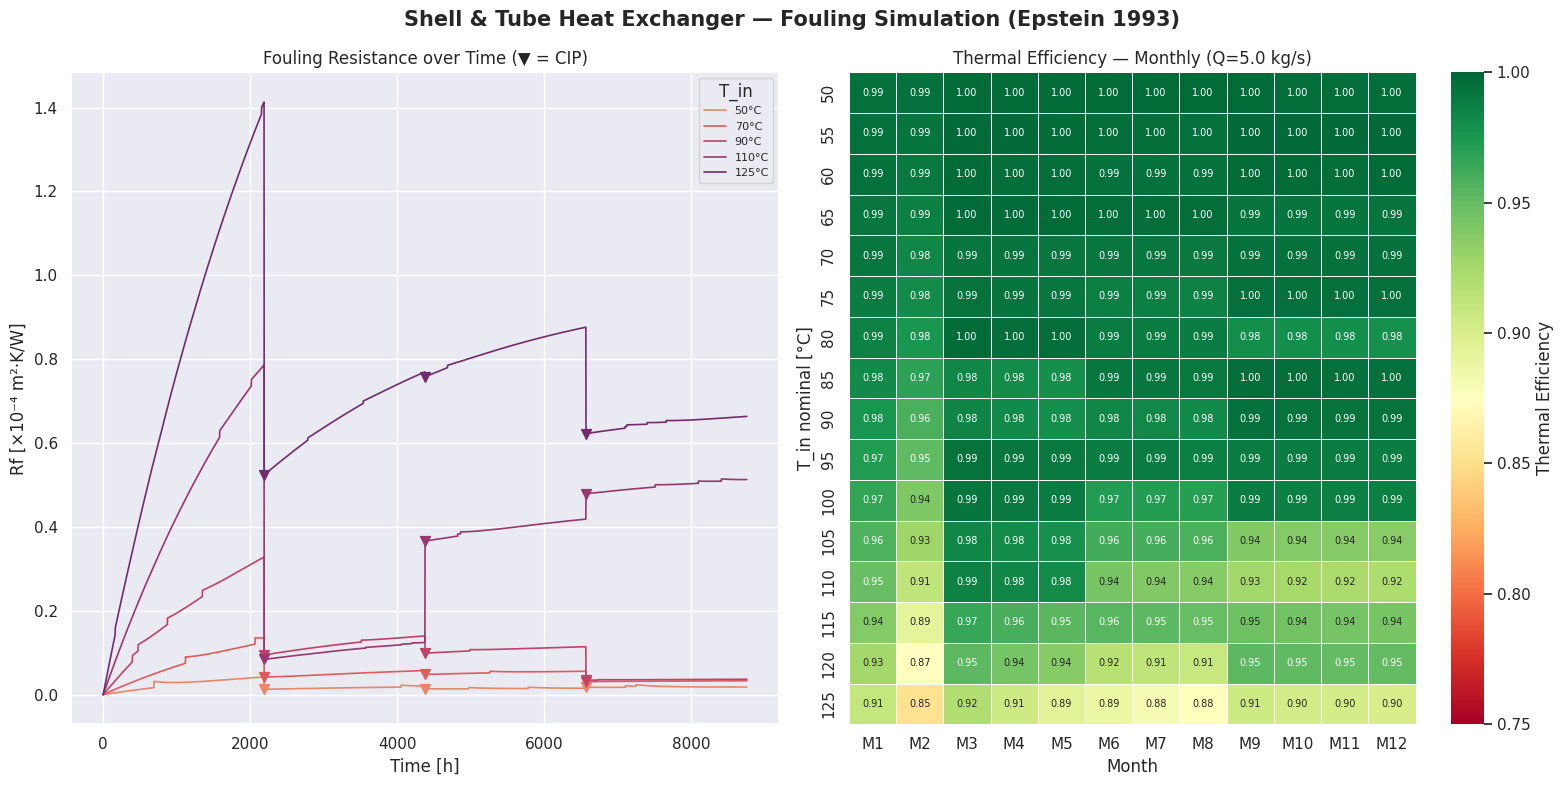

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np



sns.set_theme(style="darkgrid", palette="flare")
fig, axes = plt.subplots(1, 2, figsize=(16, 8), squeeze=False)
fig.suptitle("Shell & Tube Heat Exchanger — Fouling Simulation (Epstein 1993)",
             fontsize=15, fontweight="bold")

# ── 1. Fouling curves — filter by nominal T, fixed flow rate ──────
ax1 = axes[0, 0]
temps_to_plot = [50, 70, 90, 110, 125]
palette = sns.color_palette("flare", len(temps_to_plot))

for color, T in zip(palette, temps_to_plot):
    # Use scenario_id to get a single clean series (m_dot=5.0)
    sub = df[df["scenario_id"] == f"T{T}_Q5.0"].copy()
    ax1.plot(sub["time_h"], sub["Rf_m2K_W"] * 1e4,
             color=color, lw=1.2, label=f"{T}°C")
    # Mark CIP events
    cip = sub[sub["cip_event"] == 1]
    ax1.scatter(cip["time_h"], cip["Rf_m2K_W"] * 1e4,
                color=color, marker="v", s=50, zorder=5)

ax1.set_title("Fouling Resistance over Time (▼ = CIP)")
ax1.set_xlabel("Time [h]")
ax1.set_ylabel("Rf [×10⁻⁴ m²·K/W]")
ax1.legend(title="T_in", fontsize=8)

# ── 2. Heatmap — one row per temperature, one col per month ───────
ax2 = axes[0, 1]

# Sample one monthly point per scenario (fixed flow rate)
fixed_flow = df[df["m_dot_nominal_kg_s"] == 5.0].copy()
month_hours = [730 * m for m in range(1, 13)]   # hours at end of each month

rows = []

for T in sorted(fixed_flow["scenario_id"].str.extract(r"T(\d+)_")[0].astype(int).unique()):
    sub = fixed_flow[fixed_flow["scenario_id"] == f"T{T}_Q5.0"]
    row = {"T_in_C": T}
    for m, mh in enumerate(month_hours, 1):
        idx = (sub["time_h"] - mh).abs().idxmin()
        row[f"M{m}"] = sub.loc[idx, "thermal_efficiency"]
    rows.append(row)

pivot = pd.DataFrame(rows).set_index("T_in_C")

sns.heatmap(pivot, ax=ax2, cmap="RdYlGn", vmin=0.75, vmax=1.0,
            linewidths=0.4, annot=True, fmt=".2f",
            annot_kws={"size": 7},
            cbar_kws={"label": "Thermal Efficiency"})
ax2.set_title("Thermal Efficiency — Monthly (Q=5.0 kg/s)")
ax2.set_xlabel("Month")
ax2.set_ylabel("T_in nominal [°C]")

plt.tight_layout()
plt.show()

In [11]:
s = df[df["scenario_id"] == "T125_Q5.0"].copy()
spike_h = 6570.75
window  = s[(s["time_h"] >= 6568) & (s["time_h"] <= 6574)]
print(window[["time_h", "Rf_m2K_W", "cip_event", "efficiency_total"]].to_string())

         time_h  Rf_m2K_W  cip_event  efficiency_total
681088  6568.75  0.000088          0          0.761231
681089  6569.75  0.000062          1          0.786532
681090  6570.75  0.000062          0          0.786532
681091  6571.75  0.000062          0          0.786529
681092  6572.75  0.000062          0          0.786526
681093  6573.75  0.000062          0          0.786524


In [12]:
len(df.columns)

25

In [13]:
df.head()

,scenario_id,T_in_C,T_in_K,m_dot_nominal_kg_s,time_h,Re,u_m_s,tau_w_Pa,dP_Pa,Rf_m2K_W,...,fouling_factor_TEMA,T_in_measured_C,m_dot_measured_kg_s,cip_event,cip_effectiveness,R_wall_m2K_W,U_total_W_m2K,Q_total_W,efficiency_total,degradation_source
0,T50_Q3.0,50.000000,323.150000,3.0,0.0,5743.9,0.108,0.0518,53.25,0.000000e+00,...,L,50.152359,3.030503,0,0.0,0.0001,996.1966,1159572.81,0.899489,corrosion
1,T50_Q3.0,50.537793,323.687793,3.0,1.0,5743.9,0.108,0.0518,53.25,0.000000e+00,...,L,49.480008,3.000469,0,0.0,0.0001,996.1966,1159572.81,0.899489,corrosion
2,T50_Q3.0,51.048920,324.198920,3.0,2.0,5743.9,0.108,0.0518,53.25,1.000000e-08,...,L,50.375226,2.951329,0,0.0,0.0001,996.1866,1159561.25,0.899480,corrosion
3,T50_Q3.0,51.508518,324.658518,3.0,3.0,5743.9,0.108,0.0518,53.25,1.000000e-08,...,L,50.470282,3.013190,0,0.0,0.0001,996.1866,1159561.25,0.899480,corrosion
4,T50_Q3.0,51.895207,325.045207,3.0,4.0,5743.9,0.108,0.0518,53.25,1.000000e-08,...,L,49.024482,3.033107,0,0.0,0.0001,996.1866,1159561.25,0.899480,corrosion


In [14]:
import os
# ──  Guardar dataset final ──────────────────────────────────────
df.to_csv("/kaggle/working/output/shell_tube_fouling_final.csv", index=False)
print(f" Dataset listo: {df.shape[0]:,} filas x {df.shape[1]} columnas")

os.remove("/kaggle/working/output/shell_tube_fouling_dataset.csv")
os.remove("/kaggle/working/simulate_fouling.py")

 Dataset listo: 700,800 filas x 25 columnas


# References

- Epstein, N. (1993). The fouling of heat exchangers. 14th International Heat Transfer Conference, Washington D.C.
- Polley, G.T., Wilson, D.I., Yeap, B.L., Pugh, S.J. (2002). Evaluation of laboratory fouling data for application to crude oil preheat trains. Chemical Engineering Research and Design, 80(7), 713–727.
- Kern, D.Q., Seaton, R.E. (1959). A theoretical analysis of thermal surface fouling. British Chemical Engineering, 4(5), 258–262.
- Incropera, F.P., DeWitt, D.P. (2002). Fundamentals of Heat and Mass Transfer, 5th ed. Wiley.
- Sinnott, R.K. (2005). Chemical Engineering Design, 4th ed. Elsevier.